In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
import json
import shutil
import warnings
warnings.filterwarnings('ignore')

from diffusers import StableDiffusionPipeline, DDIMScheduler

MODEL_ID          = "CompVis/stable-diffusion-v1-4"
DEVICE            = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE             = torch.float16 if DEVICE == "cuda" else torch.float32

N_INFERENCE_STEPS = 50       
VARIANCE_WINDOW   = 15       
IMAGE_SIZE        = 512
CFG_SCALE         = 7.5

os.makedirs("data/generated/baseline",     exist_ok=True)
os.makedirs("data/generated/experimental", exist_ok=True)
os.makedirs("data/trajectories",           exist_ok=True)
os.makedirs("data/annotations",            exist_ok=True)
os.makedirs("results/figures",             exist_ok=True)

print(f"Device:           {DEVICE}")
print(f"Dtype:            {DTYPE}")
print(f"Model:            {MODEL_ID}")
print(f"Inference steps:  {N_INFERENCE_STEPS}")
print(f"Variance window:  last {VARIANCE_WINDOW} steps (i < {VARIANCE_WINDOW} → t=0..{VARIANCE_WINDOW-1})")
print(f"Image size:       {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"CFG scale:        {CFG_SCALE}")

Device:           cuda
Dtype:            torch.float16
Model:            CompVis/stable-diffusion-v1-4
Inference steps:  50
Variance window:  last 15 steps (i < 15 → t=0..14)
Image size:       512x512
CFG scale:        7.5


Loading Stable Diffusion pipeline...
(This downloads ~4GB on first run)



Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Pipeline loaded with VRAM optimisations:
  model_cpu_offload ✅  |  attention_slicing ✅  |  vae_slicing ✅
Scheduler: DDIMScheduler

GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM total: 6.4 GB  |  currently allocated: 0.00 GB

DDIM timesteps: first=981, last=1

Variance window alpha check:
  i=0  (last step):      alpha = 0.99830
  i=14 (window start):   alpha = 0.62239
  Window span: [0.622 → 0.998]

✅ ALPHA CHECK PASSED: 0.622 is in [0.30, 0.90]


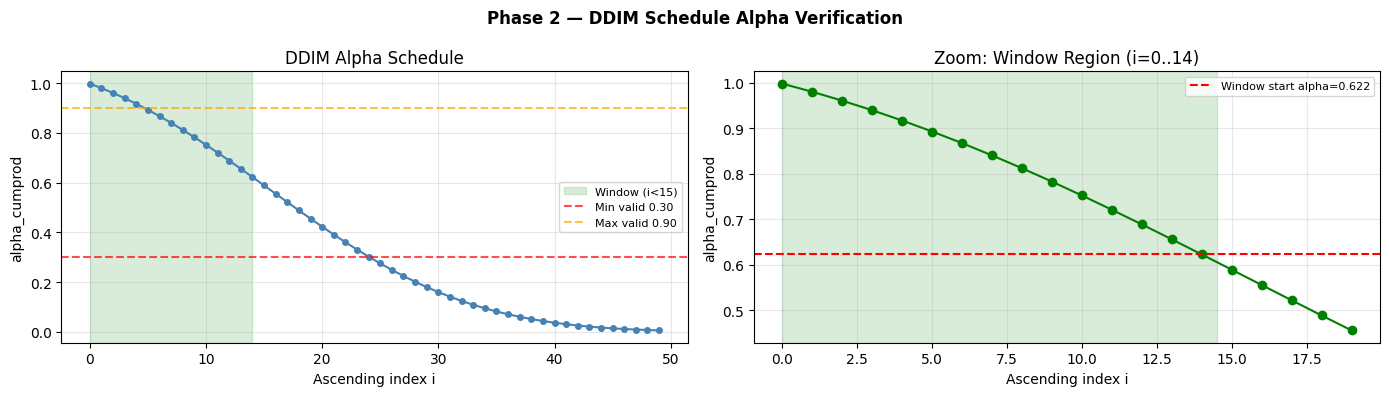

Saved: results/figures/phase2_alpha_schedule.png


In [ ]:
print("Loading Stable Diffusion pipeline...")
print("(This downloads ~4GB on first run)\n")

pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=DTYPE,
    safety_checker=None,
    requires_safety_checker=False
)

pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(DEVICE)


pipe.enable_model_cpu_offload()  
pipe.enable_attention_slicing()  
pipe.enable_vae_slicing()         

print("Pipeline loaded with VRAM optimisations:")
print("  model_cpu_offload ✅  |  attention_slicing ✅  |  vae_slicing ✅")
print(f"Scheduler: {type(pipe.scheduler).__name__}")

if torch.cuda.is_available():
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    alloc_gb = torch.cuda.memory_allocated() / 1e9
    print(f"\nGPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM total: {total_gb:.1f} GB  |  currently allocated: {alloc_gb:.2f} GB")


pipe.scheduler.set_timesteps(N_INFERENCE_STEPS)

all_alphas_cumprod = pipe.scheduler.alphas_cumprod 
ddim_timesteps     = pipe.scheduler.timesteps.cpu().numpy()  

print(f"\nDDIM timesteps: first={ddim_timesteps[0]}, last={ddim_timesteps[-1]}")

alphas_at_ascending = [
    all_alphas_cumprod[ddim_timesteps[N_INFERENCE_STEPS - 1 - i]].item()
    for i in range(N_INFERENCE_STEPS)
]

window_start_alpha = alphas_at_ascending[VARIANCE_WINDOW - 1]
window_end_alpha   = alphas_at_ascending[0]

print(f"\nVariance window alpha check:")
print(f"  i=0  (last step):      alpha = {window_end_alpha:.5f}")
print(f"  i=14 (window start):   alpha = {window_start_alpha:.5f}")
print(f"  Window span: [{window_start_alpha:.3f} → {window_end_alpha:.3f}]")

if window_start_alpha > 0.90:
    print(f"\nALPHA CHECK FAILED: {window_start_alpha:.3f} > 0.90")
    print("  Model committed at window start → variance~0. Increase VARIANCE_WINDOW.")
elif window_start_alpha < 0.30:
    print(f"\nALPHA CHECK WARNING: {window_start_alpha:.3f} < 0.30 — too noisy.")
    print("  Reduce VARIANCE_WINDOW.")
else:
    print(f"\n✅ ALPHA CHECK PASSED: {window_start_alpha:.3f} is in [0.30, 0.90]")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(range(N_INFERENCE_STEPS), alphas_at_ascending, 'o-', color='steelblue', ms=4)
axes[0].axvspan(0, VARIANCE_WINDOW - 1, alpha=0.15, color='green', label=f'Window (i<{VARIANCE_WINDOW})')
axes[0].axhline(0.30, color='red',    ls='--', alpha=0.7, label='Min valid 0.30')
axes[0].axhline(0.90, color='orange', ls='--', alpha=0.7, label='Max valid 0.90')
axes[0].set_xlabel('Ascending index i'); axes[0].set_ylabel('alpha_cumprod')
axes[0].set_title('DDIM Alpha Schedule'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(range(VARIANCE_WINDOW + 5), alphas_at_ascending[:VARIANCE_WINDOW + 5],
             'o-', color='green', ms=6)
axes[1].axvspan(0, VARIANCE_WINDOW - 0.5, alpha=0.15, color='green')
axes[1].axhline(window_start_alpha, color='red', ls='--',
                label=f'Window start alpha={window_start_alpha:.3f}')
axes[1].set_xlabel('Ascending index i'); axes[1].set_ylabel('alpha_cumprod')
axes[1].set_title(f'Zoom: Window Region (i=0..{VARIANCE_WINDOW-1})')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.suptitle('Phase 2 — DDIM Schedule Alpha Verification', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/phase2_alpha_schedule.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/phase2_alpha_schedule.png")

In [ ]:
@torch.no_grad()
def encode_prompt(prompt: str, device=DEVICE):
    tokenizer    = pipe.tokenizer
    text_encoder = pipe.text_encoder

    def tokenize(text):
        return tokenizer(
            [text],
            padding="max_length",
            max_length=tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt"
        ).input_ids.to(device)

    text_emb = text_encoder(tokenize(prompt))[0]
    null_emb = text_encoder(tokenize(""))[0]
    return text_emb, null_emb

t_emb, n_emb = encode_prompt("A red apple")
print(f"text_emb shape: {t_emb.shape}  |  dtype: {t_emb.dtype}")
print(f"null_emb shape: {n_emb.shape}")
print("✅ encode_prompt working")

text_emb shape: torch.Size([1, 77, 768])  |  dtype: torch.float16
null_emb shape: torch.Size([1, 77, 768])
✅ encode_prompt working


In [ ]:
@torch.no_grad()
def compute_trajectory_variance(
    prompt: str,
    seed: int,
    cfg_scale: float     = 7.5,
    num_steps: int       = N_INFERENCE_STEPS,
    variance_window: int = VARIANCE_WINDOW,
    return_image: bool   = True
):

    unet      = pipe.unet
    vae       = pipe.vae
    scheduler = pipe.scheduler

    scheduler.set_timesteps(num_steps)
    timesteps = scheduler.timesteps  

    text_emb, null_emb = encode_prompt(prompt)

    generator = torch.Generator(device=DEVICE).manual_seed(seed)
    latent = torch.randn(
        (1, unet.config.in_channels, IMAGE_SIZE // 8, IMAGE_SIZE // 8),
        generator=generator,
        device=DEVICE,
        dtype=DTYPE
    ) * scheduler.init_noise_sigma

    x0_window = []  

    for step_idx, t in enumerate(timesteps):

        latent_in  = torch.cat([latent, latent])
        text_in    = torch.cat([null_emb, text_emb])

        noise_pred_both = unet(
            latent_in, t, encoder_hidden_states=text_in
        ).sample

        noise_uncond, noise_cond = noise_pred_both.chunk(2)
        noise_pred = noise_uncond + cfg_scale * (noise_cond - noise_uncond)
        alpha_t  = scheduler.alphas_cumprod[t].to(dtype=torch.float32)
        x0_est   = (latent.float() - (1 - alpha_t).sqrt() * noise_pred.float()) / alpha_t.sqrt()

        if (num_steps - 1 - step_idx) < variance_window:
            x0_window.append(x0_est.cpu().numpy())  

        latent = scheduler.step(noise_pred, t, latent).prev_sample

    assert len(x0_window) == variance_window, (
        f"Expected {variance_window} estimates, got {len(x0_window)}"
    )
    x0_stack = np.array(x0_window).squeeze(1)
    variance  = float(np.var(x0_stack, axis=0).mean())

    image = None
    if return_image:
        decoded = vae.decode(latent.to(DTYPE) / vae.config.scaling_factor).sample
        decoded = (decoded.float().clamp(-1, 1) + 1) / 2
        image   = (decoded[0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

    torch.cuda.empty_cache()
    return variance, image, x0_stack


print("compute_trajectory_variance() defined ✅")
print(f"  Window: i < {VARIANCE_WINDOW} → last {VARIANCE_WINDOW} of {N_INFERENCE_STEPS} steps")
print(f"  x0 arithmetic: float32 (safe from fp16 NaN)")
print(f"  Memory: CPU transfer per step, cache cleared per image")

compute_trajectory_variance() defined ✅
  Window: i < 15 → last 15 of 50 steps
  x0 arithmetic: float32 (safe from fp16 NaN)
  Memory: CPU transfer per step, cache cleared per image


SANITY CHECK: Custom vs Standard Pipeline
Prompt: 'A red apple on a wooden table'  |  Seed: 42

Running standard pipeline...


  0%|          | 0/50 [00:00<?, ?it/s]

Standard done. Shape: (512, 512, 3)
Running custom tracking pipeline...
Custom done. Shape: (512, 512, 3)
Trajectory variance: 0.00251193

Mean |diff|: 0.0109  (0.004% of range)
Max  |diff|: 1.0000

✅ SANITY CHECK PASSED: 0.0109 < 2.55
   Tracking loop does NOT alter generation.

✅ Variance non-zero and finite: 0.00251193


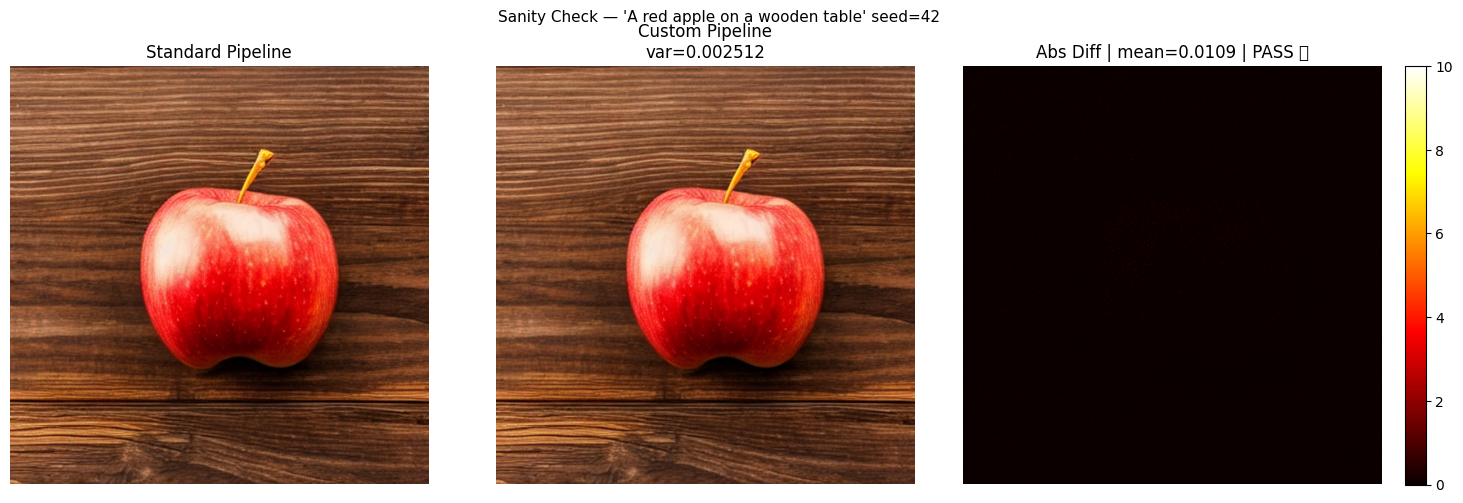

Saved: results/figures/phase2_sanity_check.png


In [ ]:
SANITY_PROMPT = "A red apple on a wooden table"
SANITY_SEED   = 42

print("=" * 60)
print("SANITY CHECK: Custom vs Standard Pipeline")
print("=" * 60)
print(f"Prompt: '{SANITY_PROMPT}'  |  Seed: {SANITY_SEED}")

print("\nRunning standard pipeline...")
gen_std = torch.Generator(device=DEVICE).manual_seed(SANITY_SEED)
std_out = pipe(
    SANITY_PROMPT,
    num_inference_steps=N_INFERENCE_STEPS,
    guidance_scale=CFG_SCALE,
    generator=gen_std,
    output_type="np"
)
std_img = (std_out.images[0] * 255).astype(np.uint8)
torch.cuda.empty_cache()
print(f"Standard done. Shape: {std_img.shape}")

print("Running custom tracking pipeline...")
cust_var, cust_img, cust_x0 = compute_trajectory_variance(
    SANITY_PROMPT, seed=SANITY_SEED, cfg_scale=CFG_SCALE
)
print(f"Custom done. Shape: {cust_img.shape}")
print(f"Trajectory variance: {cust_var:.8f}")

diff     = np.abs(std_img.astype(np.float32) - cust_img.astype(np.float32))
mean_d   = diff.mean()
PASS_THR = 2.55
passed   = mean_d < PASS_THR

print(f"\nMean |diff|: {mean_d:.4f}  ({mean_d/255*100:.3f}% of range)")
print(f"Max  |diff|: {diff.max():.4f}")

if passed:
    print(f"\n✅ SANITY CHECK PASSED: {mean_d:.4f} < {PASS_THR}")
    print("   Tracking loop does NOT alter generation.")
else:
    print(f"\n❌ SANITY CHECK FAILED: {mean_d:.4f} >= {PASS_THR}")
    print("   Check: (1) seed applied correctly, (2) init_noise_sigma applied,")
    print("          (3) scheduler.set_timesteps args match, (4) fp16/fp32 cast")

print()
if np.isfinite(cust_var) and cust_var > 1e-8:
    print(f"✅ Variance non-zero and finite: {cust_var:.8f}")
elif not np.isfinite(cust_var):
    print(f"❌ Variance is not finite ({cust_var}) — NaN/Inf. Check fp16 casting.")
else:
    print(f"⚠️  Variance near-zero ({cust_var:.2e}) — window alpha may be too high.")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(std_img);  axes[0].set_title("Standard Pipeline"); axes[0].axis('off')
axes[1].imshow(cust_img); axes[1].set_title(f"Custom Pipeline\nvar={cust_var:.6f}"); axes[1].axis('off')
im = axes[2].imshow(diff.mean(axis=2), cmap='hot', vmin=0, vmax=10)
axes[2].set_title(f"Abs Diff | mean={mean_d:.4f} | {'PASS ✅' if passed else 'FAIL ❌'}"); axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.suptitle(f"Sanity Check — '{SANITY_PROMPT}' seed={SANITY_SEED}", fontsize=11)
plt.tight_layout()
plt.savefig('results/figures/phase2_sanity_check.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/phase2_sanity_check.png")

In [ ]:
PROMPT_CONFIG = [

    {
        "id": "SC1", "category": "Single-Concept",
        "prompt": "A single red apple",
        "yolo_expected": ["apple"], "yolo_counts": {"apple": 1},
        "yolo_forbidden": [], "manual": False
    },
    {
        "id": "SC2", "category": "Single-Concept",
        "prompt": "A blue coffee mug",
        "yolo_expected": ["cup"], "yolo_counts": {"cup": 1},   # COCO: 'cup' covers mugs
        "yolo_forbidden": [], "manual": False
    },
    {
        "id": "SC3", "category": "Single-Concept",
        "prompt": "A yellow sunflower",
        "yolo_expected": ["potted plant"], "yolo_counts": {"potted plant": 1},
        "yolo_forbidden": [], "manual": False
    },
    {
        "id": "SC4", "category": "Single-Concept",
        "prompt": "A black leather shoe",
        "yolo_expected": [], "yolo_counts": {},
        "yolo_forbidden": [], "manual": True,
        "note": "shoe not in COCO/YOLOv8 vocab. CLIP score is sole automated signal."
    },
    {
        "id": "AM1", "category": "Ambiguous",
        "prompt": "A fruit",
        "yolo_expected": ["banana", "apple", "orange"], "yolo_counts": {},
        "yolo_forbidden": [], "manual": False,
        "note": "Accept any single fruit. Hallucination = 2+ distinct fruits."
    },
    {
        "id": "AM2", "category": "Ambiguous",
        "prompt": "A vehicle",
        "yolo_expected": ["car", "truck", "bus", "motorcycle", "bicycle"],
        "yolo_counts": {}, "yolo_forbidden": [], "manual": False
    },
    {
        "id": "AM3", "category": "Ambiguous",
        "prompt": "An animal",
        "yolo_expected": ["cat", "dog", "bird", "horse", "sheep", "cow"],
        "yolo_counts": {}, "yolo_forbidden": [], "manual": False
    },
    {
        "id": "AM4", "category": "Ambiguous",
        "prompt": "A tool",
        "yolo_expected": ["scissors", "knife"], 
        "yolo_counts": {}, "yolo_forbidden": [], "manual": False,
        "note": "COCO tools = scissors/knife only. Wrench/hammer not in COCO — CLIP supplements."
    },

    {
        "id": "CF1", "category": "Conflicting", "prompt": "Transparent wood",
        "yolo_expected": [], "yolo_counts": {}, "yolo_forbidden": [], "manual": True
    },
    {
        "id": "CF2", "category": "Conflicting", "prompt": "Square circle",
        "yolo_expected": [], "yolo_counts": {}, "yolo_forbidden": [], "manual": True
    },
    {
        "id": "CF3", "category": "Conflicting", "prompt": "Frozen fire",
        "yolo_expected": [], "yolo_counts": {}, "yolo_forbidden": [], "manual": True
    },
    {
        "id": "CF4", "category": "Conflicting", "prompt": "Silent thunder",
        "yolo_expected": [], "yolo_counts": {}, "yolo_forbidden": [], "manual": True
    },

    {
        "id": "CO1", "category": "Compositional",
        "prompt": "Cat on chair",
        "yolo_expected": ["cat", "chair"], "yolo_counts": {"cat": 1, "chair": 1},
        "yolo_forbidden": [], "manual": False
    },
    {
        "id": "CO2", "category": "Compositional",
        "prompt": "Book under lamp",
        "yolo_expected": ["book"], "yolo_counts": {"book": 1}, 
        "yolo_forbidden": [], "manual": False,
        "note": "lamp not in COCO. CLIP handles lamp presence."
    },
    {
        "id": "CO3", "category": "Compositional",
        "prompt": "Apple in bowl",
        "yolo_expected": ["apple", "bowl"], "yolo_counts": {"apple": 1, "bowl": 1},
        "yolo_forbidden": [], "manual": False
    },
    {
        "id": "CO4", "category": "Compositional",
        "prompt": "Bird on branch",
        "yolo_expected": ["bird"], "yolo_counts": {"bird": 1},  
        "yolo_forbidden": [], "manual": False,
        "note": "branch not in COCO. CLIP handles branch context."
    },

    {
        "id": "NE1", "category": "Negation",
        "prompt": "Car, no wheels",
        "yolo_expected": ["car"], "yolo_counts": {"car": 1},
        "yolo_forbidden": [], "manual": False,
        "note": "wheel not in COCO. Wheel visibility requires CLIP/manual."
    },
    {
        "id": "NE2", "category": "Negation",
        "prompt": "Face, no eyes",
        "yolo_expected": ["person"], "yolo_counts": {"person": 1},
        "yolo_forbidden": [], "manual": False,
        "note": "eyes not in COCO. CLIP checks for eye absence."
    },
    {
        "id": "NE3", "category": "Negation",
        "prompt": "Tree, no leaves",
        "yolo_expected": [], "yolo_counts": {}, "yolo_forbidden": [],
        "manual": True, "note": "tree and leaf both not in COCO."
    },
    {
        "id": "NE4", "category": "Negation",
        "prompt": "House, no door",
        "yolo_expected": [], "yolo_counts": {}, "yolo_forbidden": [],
        "manual": True, "note": "house and door both not in COCO."
    },
]

auto_count   = sum(1 for p in PROMPT_CONFIG if not p['manual'])
manual_count = sum(1 for p in PROMPT_CONFIG if p['manual'])

print(f"Total prompts:       {len(PROMPT_CONFIG)}")
print(f"Auto (YOLO + CLIP):  {auto_count}")
print(f"Manual (CLIP only):  {manual_count}")
print()
print(f"{'ID':<5} {'Category':<18} {'Prompt':<32} {'Validation'}")
print("-" * 72)
for p in PROMPT_CONFIG:
    mode = 'MANUAL (CLIP only)' if p['manual'] else 'AUTO (YOLO + CLIP)'
    print(f"{p['id']:<5} {p['category']:<18} {p['prompt']:<32} {mode}")

with open('data/prompt_config.json', 'w') as f:
    json.dump(PROMPT_CONFIG, f, indent=2)
print("\n✅ Saved: data/prompt_config.json  (import this into Kaggle for Phase 3)")

Total prompts:       20
Auto (YOLO + CLIP):  13
Manual (CLIP only):  7

ID    Category           Prompt                           Validation
------------------------------------------------------------------------
SC1   Single-Concept     A single red apple               AUTO (YOLO + CLIP)
SC2   Single-Concept     A blue coffee mug                AUTO (YOLO + CLIP)
SC3   Single-Concept     A yellow sunflower               AUTO (YOLO + CLIP)
SC4   Single-Concept     A black leather shoe             MANUAL (CLIP only)
AM1   Ambiguous          A fruit                          AUTO (YOLO + CLIP)
AM2   Ambiguous          A vehicle                        AUTO (YOLO + CLIP)
AM3   Ambiguous          An animal                        AUTO (YOLO + CLIP)
AM4   Ambiguous          A tool                           AUTO (YOLO + CLIP)
CF1   Conflicting        Transparent wood                 MANUAL (CLIP only)
CF2   Conflicting        Square circle                    MANUAL (CLIP only)
CF3   Conflictin

In [ ]:
from ultralytics import YOLO
import open_clip
from PIL import Image

print("=" * 60)
print("PRE-FLIGHT CHECKLIST")
print("=" * 60)
checklist = {}

_, _, free = shutil.disk_usage("/")
free_gb  = free / 1e9
check1   = free_gb >= 10.0
checklist['disk_space'] = check1
print(f"\n[1] Disk space: {'✅' if check1 else '❌'}")
print(f"    Free: {free_gb:.1f} GB  (need 10 GB)")

if torch.cuda.is_available():
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    check2 = total_vram >= 5.0
    print(f"\n[2] GPU VRAM: {'✅' if check2 else '❌'}")
    print(f"    {torch.cuda.get_device_name(0)}: {total_vram:.1f} GB")
    if total_vram < 15:
        print(f"    ⚠️  < 15 GB: VRAM optimisations enabled. Phase 3 recommended on Kaggle (P100 16GB).")
else:
    check2 = False
    print(f"\n[2] GPU VRAM: ❌ No CUDA GPU")
checklist['gpu_vram'] = check2

print(f"\n[3] YOLO (YOLOv8x):")
try:
    yolo = YOLO("yolov8x.pt")
    dummy_pil = Image.fromarray(np.random.randint(0, 255, (512, 512, 3), dtype=np.uint8))
    yolo(dummy_pil, verbose=False)
    yolo_classes = list(yolo.names.values())

    required = ['apple','cup','potted plant','car','truck','bus','cat','dog',
                'bird','scissors','knife','chair','book','bowl','person']
    missing  = [c for c in required if c not in yolo_classes]

    check3 = True
    print(f"    ✅ YOLOv8x loaded | {len(yolo_classes)} classes")
    if missing:
        print(f"    ⚠️  Not in COCO vocab: {missing}")
    else:
        print(f"    ✅ All required classes present in YOLO vocab")
except Exception as e:
    check3 = False
    print(f"    ❌ {e}")
checklist['yolo'] = check3

print(f"\n[4] CLIP (ViT-L/14, OpenCLIP):")
try:
    clip_model, _, clip_prep = open_clip.create_model_and_transforms('ViT-L-14', pretrained='openai')
    clip_model   = clip_model.to(DEVICE)
    clip_tok     = open_clip.get_tokenizer('ViT-L-14')

    dummy_img = clip_prep(Image.fromarray(
        np.random.randint(0, 255, (512, 512, 3), dtype=np.uint8)
    )).unsqueeze(0).to(DEVICE)
    dummy_txt = clip_tok(["A red apple"]).to(DEVICE)

    with torch.no_grad(), torch.cuda.amp.autocast():
        i_feat = clip_model.encode_image(dummy_img)
        t_feat = clip_model.encode_text(dummy_txt)
        i_feat /= i_feat.norm(dim=-1, keepdim=True)
        t_feat /= t_feat.norm(dim=-1, keepdim=True)
        score  = (i_feat @ t_feat.T).item()

    check4 = True
    print(f"    ✅ CLIP loaded | test score: {score:.4f} (random image, expect ~0.1-0.3)")
except Exception as e:
    check4 = False
    print(f"    ❌ {e}")
checklist['clip'] = check4

print(f"\n[5] End-to-end generation + variance:")
try:
    v, img, _ = compute_trajectory_variance("A blue cup", seed=0, cfg_scale=7.5)
    assert np.isfinite(v) and v > 1e-10 and img.shape == (512, 512, 3)
    check5 = True
    print(f"    ✅ Done | variance={v:.8f} | image shape={img.shape}")
except Exception as e:
    check5 = False
    print(f"    ❌ {e}")
checklist['pipeline_e2e'] = check5

check6 = 0.30 < window_start_alpha < 0.90
checklist['alpha_range'] = check6
print(f"\n[6] Alpha range: {'✅' if check6 else '❌'}  (alpha={window_start_alpha:.4f})")

print()
print("=" * 60)
print("SUMMARY")
print("=" * 60)
all_pass = True
for k, v in checklist.items():
    print(f"  {k:<20} {'✅ PASS' if v else '❌ FAIL'}")
    if not v:
        all_pass = False

print()
if all_pass:
    print("✅ ALL CHECKS PASSED — Phase 2 complete. Ready for Phase 3.")
else:
    print("❌ Fix failing checks before Phase 3.")

with open('data/preflight_checklist.json', 'w') as f:
    json.dump({**checklist, 'all_passed': all_pass,
               'window_start_alpha': window_start_alpha}, f, indent=2)
print("Saved: data/preflight_checklist.json")

print()
print("=" * 60)
print("VRAM STRESS TEST — 3 consecutive generations")
print("=" * 60)
stress_prompts = ["A red apple", "Cat on chair", "A blue coffee mug"]

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

for i, prompt in enumerate(stress_prompts):
    before = torch.cuda.memory_allocated() / 1e6 if torch.cuda.is_available() else 0
    v, img, _ = compute_trajectory_variance(prompt, seed=i)
    peak = torch.cuda.max_memory_allocated() / 1e6 if torch.cuda.is_available() else 0
    print(f"[{i+1}] {prompt:<30} var={v:.6f}  peak VRAM={peak:.0f} MB")
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

print()
total_vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0
print("DECISION:")
if total_vram_gb >= 15:
    print("  ✅ VRAM >= 15GB — run Phase 3 locally")
else:
    print("  ⚠️  VRAM < 15GB — upload Phase3_Generation.ipynb to Kaggle (free P100 16GB)")
    print("     Files to upload to Kaggle:")
    print("       1. Phase3_Generation.ipynb")
    print("       2. data/prompt_config.json")

PRE-FLIGHT CHECKLIST

[1] Disk space: ✅
    Free: 160.7 GB  (need 10 GB)

[2] GPU VRAM: ✅
    NVIDIA GeForce RTX 4050 Laptop GPU: 6.4 GB
    ⚠️  < 15 GB: VRAM optimisations enabled. Phase 3 recommended on Kaggle (P100 16GB).

[3] YOLO (YOLOv8x):
    ✅ YOLOv8x loaded | 80 classes
    ✅ All required classes present in YOLO vocab

[4] CLIP (ViT-L/14, OpenCLIP):
    ✅ CLIP loaded | test score: 0.1454 (random image, expect ~0.1-0.3)

[5] End-to-end generation + variance:
    ✅ Done | variance=0.00238474 | image shape=(512, 512, 3)

[6] Alpha range: ✅  (alpha=0.6224)

SUMMARY
  disk_space           ✅ PASS
  gpu_vram             ✅ PASS
  yolo                 ✅ PASS
  clip                 ✅ PASS
  pipeline_e2e         ✅ PASS
  alpha_range          ✅ PASS

✅ ALL CHECKS PASSED — Phase 2 complete. Ready for Phase 3.
Saved: data/preflight_checklist.json

VRAM STRESS TEST — 3 consecutive generations
[1] A red apple                    var=0.002144  peak VRAM=4240 MB
[2] Cat on chair                 